<a href="https://colab.research.google.com/github/Krishrdx/ML_to_GenAI_Journey/blob/main/Month_04_Deep_Learning/Week_01_Foundation_on_DL/Day_05_Grad_admission_pred_using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("/content/Admission_Predict.csv")

In [5]:
df.sample(5)

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
316,317,298,101,2,1.5,2.0,7.86,0,0.54
235,236,326,111,5,4.5,4.0,9.23,1,0.88
354,355,297,98,2,2.5,3.0,7.67,0,0.59
21,22,325,114,4,3.0,2.0,8.40,0,0.70
388,389,296,97,2,1.5,2.0,7.80,0,0.49


In [6]:
df.shape

(400, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


In [12]:
df.drop(columns=['Serial No.'], inplace= True)

In [15]:
x = df.iloc[:,:7]
y = df.iloc[:,-1]

In [16]:
x.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0


In [18]:
y.head()

,Chance of Admit
0,0.92
1,0.76
2,0.72
3,0.80
4,0.65


In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state =1)

In [22]:
from sklearn.preprocessing import minmax_scale
x_train_scaled = minmax_scale(x_train)
x_test_scaled = minmax_scale(x_test)

In [23]:
x_train_scaled


array([[0.22      , 0.17857143, 0.25      , ..., 0.42857143, 0.25      ,
        1.        ],
       [0.88      , 0.96428571, 1.        , ..., 0.85714286, 0.91911765,
        1.        ],
       [0.3       , 0.71428571, 0.5       , ..., 0.57142857, 0.53308824,
        0.        ],
       ...,
       [0.7       , 0.53571429, 0.5       , ..., 0.57142857, 0.70220588,
        1.        ],
       [0.72      , 0.67857143, 1.        , ..., 0.71428571, 0.74632353,
        1.        ],
       [0.2       , 0.46428571, 0.        , ..., 0.14285714, 0.22058824,
        0.        ]])

In [26]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [27]:
model = Sequential()

In [41]:
model.add(Dense(7,activation='relu',input_dim= 7))
model.add(Dense(4,activation='relu',input_dim=4))
model.add(Dense(1,activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │            14 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 245 (984.00 B)

 Trainable params: 115 (460.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 130 (524.00 B)

In [50]:
model.compile(loss='mean_squared_error',optimizer='adam',metrics=['mean_absolute_error'])


In [53]:
history = model.fit(x_train_scaled, y_train, epochs=100, validation_split=0.2)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0049 - mean_absolute_error: 0.0515 - val_loss: 0.0036 - val_mean_absolute_error: 0.0434
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0048 - mean_absolute_error: 0.0483 - val_loss: 0.0037 - val_mean_absolute_error: 0.0454
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0046 - mean_absolute_error: 0.0485 - val_loss: 0.0036 - val_mean_absolute_error: 0.0445
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0045 - mean_absolute_error: 0.0482 - val_loss: 0.0036 - val_mean_absolute_error: 0.0433
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0043 - mean_absolute_error: 0.0464 - val_loss: 0.0037 - val_mean_absolute_error: 0.0449
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0045 - mean_absolute_error: 0.0483 - val_loss: 0.0036 - val_mean_absolute_error: 0.0433
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0043 - mean_absolute_error: 0.0453 - val_loss: 0.003

In [45]:
y_pred = model.predict(x_test_scaled)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [46]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.7772119420383996

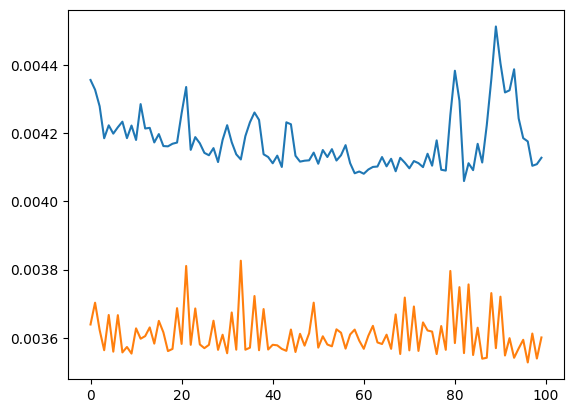

In [59]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])


In [60]:
history.history

{'loss': [0.004355577286332846,
  0.004327129572629929,
  0.004278707318007946,
  0.004184961784631014,
  0.004222787916660309,
  0.0041984571143984795,
  0.004217127338051796,
  0.004233425483107567,
  0.00418526167050004,
  0.0042220717296004295,
  0.004179894924163818,
  0.004284883849322796,
  0.004213484935462475,
  0.004215344320982695,
  0.0041726757772266865,
  0.004197102505713701,
  0.004162045195698738,
  0.0041612316854298115,
  0.004168801940977573,
  0.004172292072325945,
  0.0042580850422382355,
  0.004335000179708004,
  0.004150900989770889,
  0.004188248887658119,
  0.004170153755694628,
  0.004142152611166239,
  0.004135104361921549,
  0.004156011156737804,
  0.004115201998502016,
  0.004180076066404581,
  0.004223140422254801,
  0.0041733854450285435,
  0.004137816838920116,
  0.004122809506952763,
  0.004191289655864239,
  0.004231571685522795,
  0.004260337445884943,
  0.004238623660057783,
  0.004137973301112652,
  0.0041299546137452126,
  0.004111668094992638,
  